In [2]:
import pandas as pd
import numpy as np
from numpy.linalg import norm

nodes = pd.read_pickle("df_node_results_30_topic.pkl")
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7415 entries, 0 to 7414
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   node       7415 non-null   object
 1   text       7415 non-null   object
 2   node_emb   7415 non-null   object
 3   topic_id   7415 non-null   int64 
 4   community  7415 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 289.8+ KB


In [10]:
# 统一列名
nodes = nodes.rename(columns={
    "node": "user_id",
    "community": "community_id",
    "node_emb": "node_emb"
})

nodes = nodes[["user_id", "community_id", "node_emb"]]
nodes.head()


,user_id,community_id,node_emb
0,02myfrifeed01,18,"[-0.024345804, 0.044006918, -0.0043728794, 0.0..."
1,0boy,6,"[-0.066298805, -0.021350043, 0.036989458, -0.0..."
2,0bpm,8,"[0.015317391, 0.014721517, 0.046485335, 0.0049..."
3,0m4r,58,"[-0.060475595, -0.025443017, 0.027896618, -0.0..."
4,1001noisycameras,8,"[-0.059649102, 0.013722666, 0.017942311, -0.02..."


In [9]:
import pandas as pd
import numpy as np
from numpy.linalg import norm
from itertools import combinations
import random

from scipy.stats import ttest_ind, pearsonr
import matplotlib.pyplot as plt

# 为了可复现
random.seed(42)
np.random.seed(42)

def cos_sim(a, b, eps=1e-8):
    """Compute cosine similarity between two 1D vectors."""
    a = np.asarray(a)
    b = np.asarray(b)
    return float(np.dot(a, b) / (norm(a) * norm(b) + eps))


In [11]:
# 构造字典加速查询
# user -> embedding
embs = dict(zip(nodes["user_id"], nodes["node_emb"]))
# user -> community
comms = dict(zip(nodes["user_id"], nodes["community_id"]))

# 方便后面采样
users_all = list(embs.keys())
len(users_all), len(set(comms.values()))


(7415, 115)

In [12]:
# 生成“同社区”用户对，并计算 node2vec 相似度
K = 50   # 每个社区最多抽多少个节点，可根据机器内存适当调整

same_pairs = []

for cid, group in nodes.groupby("community_id"):
    users = list(group["user_id"])
    if len(users) < 2:
        continue

    # 限制每个社区参与采样的节点数
    if len(users) > K:
        users = random.sample(users, K)

    for u, v in combinations(users, 2):
        sim = cos_sim(embs[u], embs[v])
        same_pairs.append((u, v, cid, sim))

same_df = pd.DataFrame(
    same_pairs,
    columns=["u", "v", "community_id", "node2vec_cos"]
)
same_df["same_comm"] = 1

same_df.head(), same_df.shape


(            u            v  community_id  node2vec_cos  same_comm
 0     dotevan   markhawker             0      0.419398          1
 1     dotevan  philbaumann             0      0.574621          1
 2  markhawker  philbaumann             0      0.458261          1
 3       11011        binic             1      0.506295          1
 4       11011      pishcot             1      0.645599          1,
 (18240, 5))

In [13]:
# 生成“不同社区”用户对，并计算相似度
diff_pairs = []

# 希望不同社区样本数量和同社区差不多
target_n = len(same_df)

while len(diff_pairs) < target_n:
    u, v = random.sample(users_all, 2)
    if comms[u] == comms[v]:
        continue
    sim = cos_sim(embs[u], embs[v])
    diff_pairs.append((u, v, comms[u], comms[v], sim))

diff_df = pd.DataFrame(
    diff_pairs,
    columns=["u", "v", "comm_u", "comm_v", "node2vec_cos"]
)
diff_df["same_comm"] = 0

diff_df.head(), diff_df.shape


(                 u           v  comm_u  comm_v  node2vec_cos  same_comm
 0  iowajournalists    laurence       6      29      0.256080          0
 1    aaliyahlester     hjdavis      18       8      0.069631          0
 2         funnynow  simonwicks      18       8      0.481687          0
 3            ivant    venereal      14      61      0.259104          0
 4             yisn       tufee       2      18      0.126527          0,
 (18240, 6))

In [14]:
# 合并两类样本，计算均值和 t 检验
pairs_df = pd.concat([
    same_df[["node2vec_cos", "same_comm"]],
    diff_df[["node2vec_cos", "same_comm"]],
], ignore_index=True)

same_mean = pairs_df[pairs_df["same_comm"] == 1]["node2vec_cos"].mean()
diff_mean = pairs_df[pairs_df["same_comm"] == 0]["node2vec_cos"].mean()

print("Mean cosine (same community):     ", same_mean)
print("Mean cosine (different community):", diff_mean)

# t-test
t, p = ttest_ind(
    pairs_df[pairs_df["same_comm"] == 1]["node2vec_cos"],
    pairs_df[pairs_df["same_comm"] == 0]["node2vec_cos"],
    equal_var=False
)
print(f"t = {t:.3f}, p = {p:.3e}")


Mean cosine (same community):      0.3327553945028749
Mean cosine (different community): 0.2610858253789326
t = 42.491, p = 0.000e+00


/tmp/ipython-input-3354497007.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


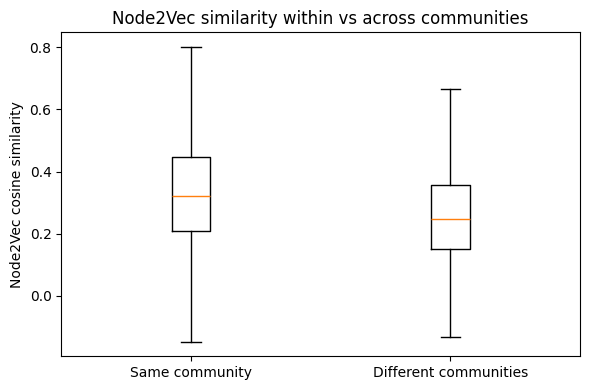

In [15]:
# 画图 1：same vs diff 的分布（箱线图 + 简单密度）
# Boxplot
fig, ax = plt.subplots(figsize=(6, 4))

data_same = pairs_df[pairs_df["same_comm"] == 1]["node2vec_cos"]
data_diff = pairs_df[pairs_df["same_comm"] == 0]["node2vec_cos"]

ax.boxplot(
    [data_same, data_diff],
    labels=["Same community", "Different communities"],
    showfliers=False
)

ax.set_ylabel("Node2Vec cosine similarity")
ax.set_title("Node2Vec similarity within vs across communities")

plt.tight_layout()
plt.show()


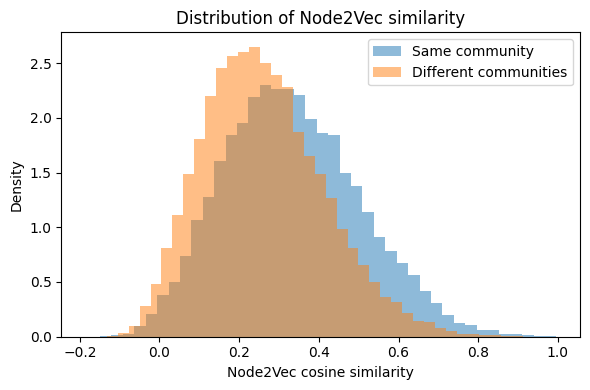

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    data_same,
    bins=40,
    density=True,
    alpha=0.5,
    label="Same community"
)
ax.hist(
    data_diff,
    bins=40,
    density=True,
    alpha=0.5,
    label="Different communities"
)

ax.set_xlabel("Node2Vec cosine similarity")
ax.set_ylabel("Density")
ax.set_title("Distribution of Node2Vec similarity")
ax.legend()

plt.tight_layout()
plt.show()


In [17]:
# 计算每个社区的 intra_sim 和 inter_sim
# intra_sim：同一个 community 内所有 pairs 的平均 cosine。
# inter_sim：该 community 里的用户和其他 community 用户的平均 cosine。

# 社区内部平均相似度
intra_sim = same_df.groupby("community_id")["node2vec_cos"].mean().rename("intra_sim")

# 为了计算“对外”的相似度，对 diff_df 做一个长表，把 comm_u 和 comm_v 都当作发出方
inter_long = pd.concat([
    diff_df[["comm_u", "node2vec_cos"]].rename(columns={"comm_u": "community_id"}),
    diff_df[["comm_v", "node2vec_cos"]].rename(columns={"comm_v": "community_id"}),
], ignore_index=True)

inter_sim = inter_long.groupby("community_id")["node2vec_cos"].mean().rename("inter_sim")

comm_sim = pd.concat([intra_sim, inter_sim], axis=1).dropna()
comm_sim["gap"] = comm_sim["intra_sim"] - comm_sim["inter_sim"]

comm_sim.head()


,intra_sim,inter_sim,gap
community_id,,,
0,0.484094,0.335468,0.148625
1,0.549938,0.326202,0.223736
2,0.330855,0.256967,0.073888
4,0.236783,0.238695,-0.001912
5,0.507697,0.312553,0.195144


In [19]:
# TODO: 把路径改成你自己的文件
comm_edges = pd.read_pickle("communities_edge.pkl")
comm_edges.head()

,community_id,size,E_in,E_out,W_in,W_out,ratio_in_edges,ratio_in_weight
0,0,5,3,4,5.0,8.0,0.428571,0.384615
1,1,4,3,1,3.0,2.0,0.750000,0.600000
2,2,190,368,295,3496.0,484.0,0.555053,0.878392
3,3,3,2,1,2.0,2.0,0.666667,0.500000
4,4,6290,27237,6664,56158.0,12751.0,0.803428,0.814959


In [20]:
# 和 ratio_in_weight 合并，并计算相关
# comm_edges 里应该有 community_id 和 ratio_in_weight
comm_all = comm_edges.merge(
    comm_sim.reset_index(),   # index 是 community_id
    on="community_id",
    how="inner"
)

comm_all[["community_id", "ratio_in_weight", "intra_sim", "inter_sim", "gap"]].head()


,community_id,ratio_in_weight,intra_sim,inter_sim,gap
0,0,0.384615,0.484094,0.335468,0.148625
1,1,0.600000,0.549938,0.326202,0.223736
2,2,0.878392,0.330855,0.256967,0.073888
3,4,0.814959,0.236783,0.238695,-0.001912
4,5,0.857143,0.507697,0.312553,0.195144


In [21]:
# 计算 Pearson 相关
r, p = pearsonr(comm_all["ratio_in_weight"], comm_all["gap"])
print(f"Correlation between ratio_in_weight and (intra - inter) similarity: r = {r:.3f}, p = {p:.3e}")


Correlation between ratio_in_weight and (intra - inter) similarity: r = 0.033, p = 7.603e-01


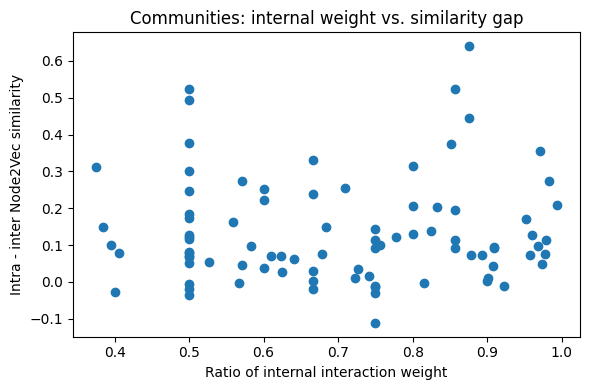

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    comm_all["ratio_in_weight"],
    comm_all["gap"]
)

ax.set_xlabel("Ratio of internal interaction weight")
ax.set_ylabel("Intra - inter Node2Vec similarity")
ax.set_title("Communities: internal weight vs. similarity gap")

plt.tight_layout()
plt.show()
